<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Examen Parcial 3 - Marilyn Michelle Jiménez Arias (U20231085)
        </td>
    </tr>
</table>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

Se cuenta con un conjunto de datos laboral compuesto por 1800 registros y 11 variables relacionadas con la jornada de trabajo, tiempo frente a pantalla, número de reuniones, descansos, trabajo fuera del horario laboral, horas de sueño, productividad y nivel de agotamiento. El objetivo de este análisis es entrenar y evaluar modelos de clasificación supervisada para predecir la variable respuesta `burnout_risk`.

Las variables disponibles en el conjunto de datos son:
- `user_id`: Identificador único del usuario.
- `day_type`: Tipo de día registrado (Weekday, Weekend).
- `work_hours`: Cantidad de horas trabajadas durante el día.
- `screen_time_hours`: Cantidad de horas de uso de pantalla durante el día.
- `meetings_count`: Número de reuniones realizadas durante el día.
- `breaks_taken`: Cantidad de descansos tomados durante la jornada.
- `after_hours_work`: Indica si la persona realizó trabajo fuera del horario laboral (0 o 1).
- `sleep_hours`: Cantidad de horas de sueño registradas.
- `task_completion_rate`: Porcentaje o tasa de finalización de tareas.
- `burnout_score`: Puntaje numérico asociado al nivel de agotamiento.
- `burnout_risk`: Variable objetivo que indica la categoría de riesgo de agotamiento (Low, Medium, High).

### a) Análisis de todas las variables predictoras y respuesta
Cargamos el conjunto de datos y observamos las primeras filas para verificar su estructura.

In [3]:
datos = pd.read_csv("Parcial 3 - DT6.csv")
datos.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


Mostramos la información de los tipos de datos y si existen valores nulos en el conjunto de datos.

In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   str    
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   str    
dtypes: float64(5), int64(4), str(2)
memory usage: 173.2 KB


Mostramos los estadísticos descriptivos generales para comprender la distribución de las variables.

In [5]:
datos.describe(include="all")

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
count,1800.000000,1800,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,Weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1527
mean,90.500000,NaN,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978,NaN
std,51.975162,NaN,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782,NaN
min,1.000000,NaN,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000,NaN
25%,45.750000,NaN,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000,NaN
50%,90.500000,NaN,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000,NaN
75%,135.250000,NaN,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500,NaN


Analizamos la distribución de frecuencias de la variable respuesta `burnout_risk`.

In [6]:
datos["burnout_risk"].value_counts()

burnout_risk
Low       1527
Medium     253
High        20
Name: count, dtype: int64

Graficamos la variable respuesta `burnout_risk` para visualizar la distribución de sus categorías.

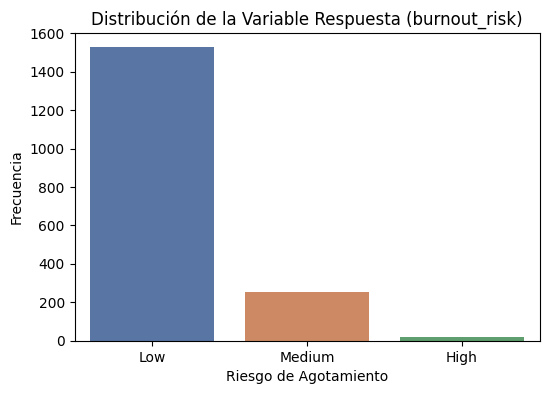

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=datos, x="burnout_risk", palette="deep", order=["Low", "Medium", "High"])
plt.title("Distribución de la Variable Respuesta (burnout_risk)")
plt.xlabel("Riesgo de Agotamiento")
plt.ylabel("Frecuencia")
plt.show()

Para la variable predictora categórica `day_type`, la transformamos a formato numérico (0 y 1) mediante una lista de comprensión, emulando la forma en que se transformaron las variables cualitativas en las clases.

In [8]:
datos["day_type_num"] = [1 if x == "Weekday" else 0 for x in datos["day_type"]]
datos[["day_type", "day_type_num"]].head()

,day_type,day_type_num
0,Weekday,1
1,Weekend,0
2,Weekend,0
3,Weekday,1
4,Weekend,0


Definimos las variables predictoras independientes y la variable respuesta, descartando la columna `user_id` ya que no aporta información al modelo, y la columna original `day_type` (utilizando la numérica en su lugar).

In [9]:
X_independientes = datos.drop(["user_id", "day_type", "burnout_risk"], axis=1)
y_dependiente = datos["burnout_risk"]

Graficamos los histogramas de todas las variables predictoras numéricas.

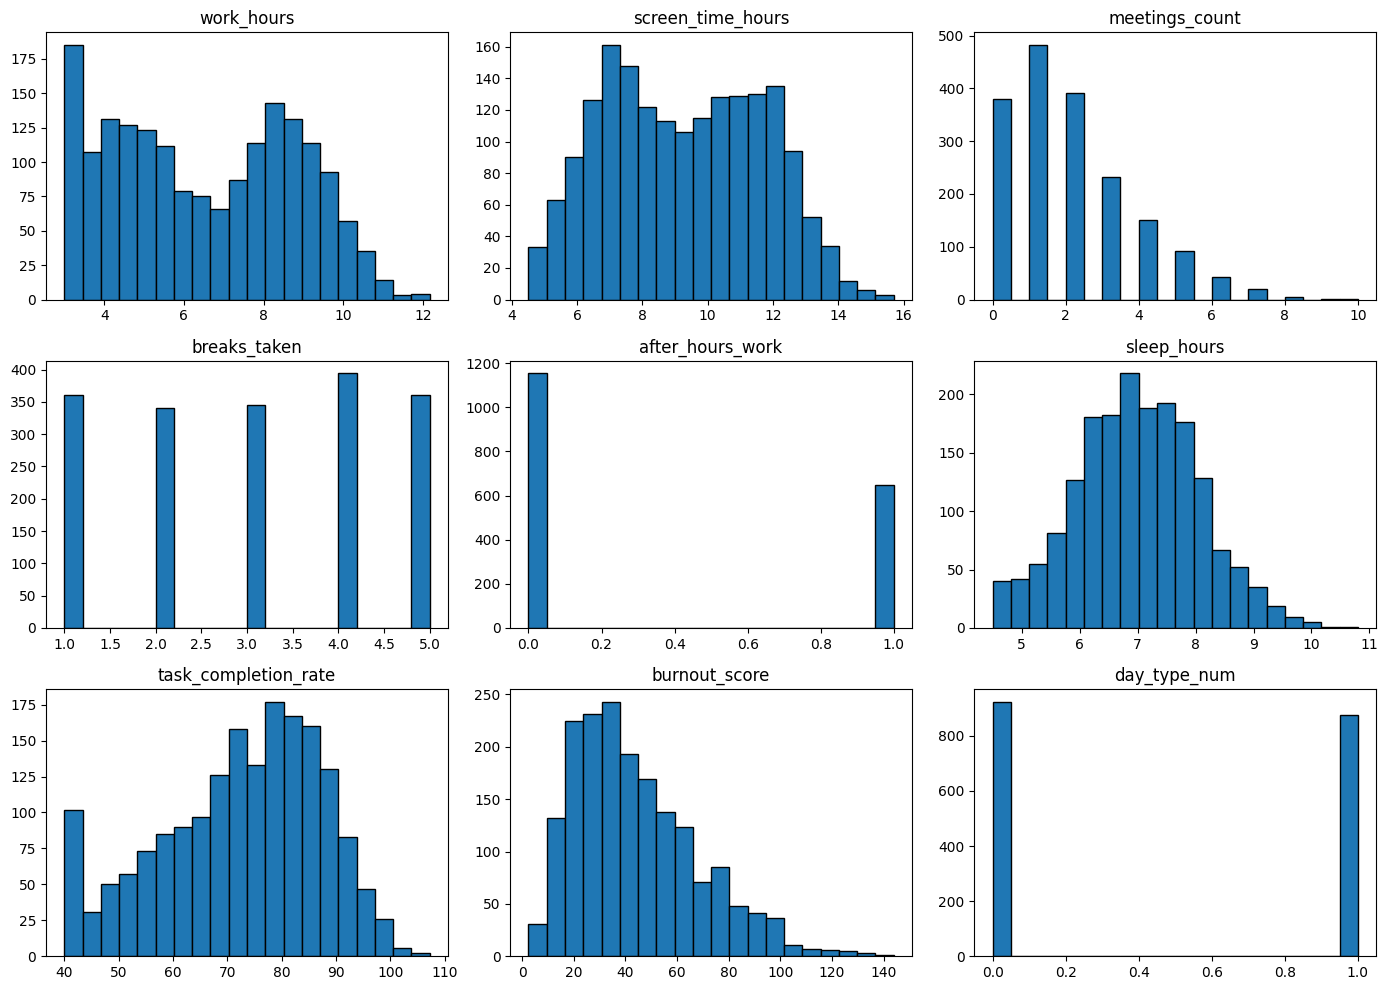

In [12]:
X_independientes.hist(figsize=(14, 10), bins=20, edgecolor="black", grid =False)
plt.tight_layout()
plt.show()

Realizamos un análisis gráfico cruzado representando la relación de las variables predictoras numéricas con la variable respuesta usando diagramas de caja (boxplots).

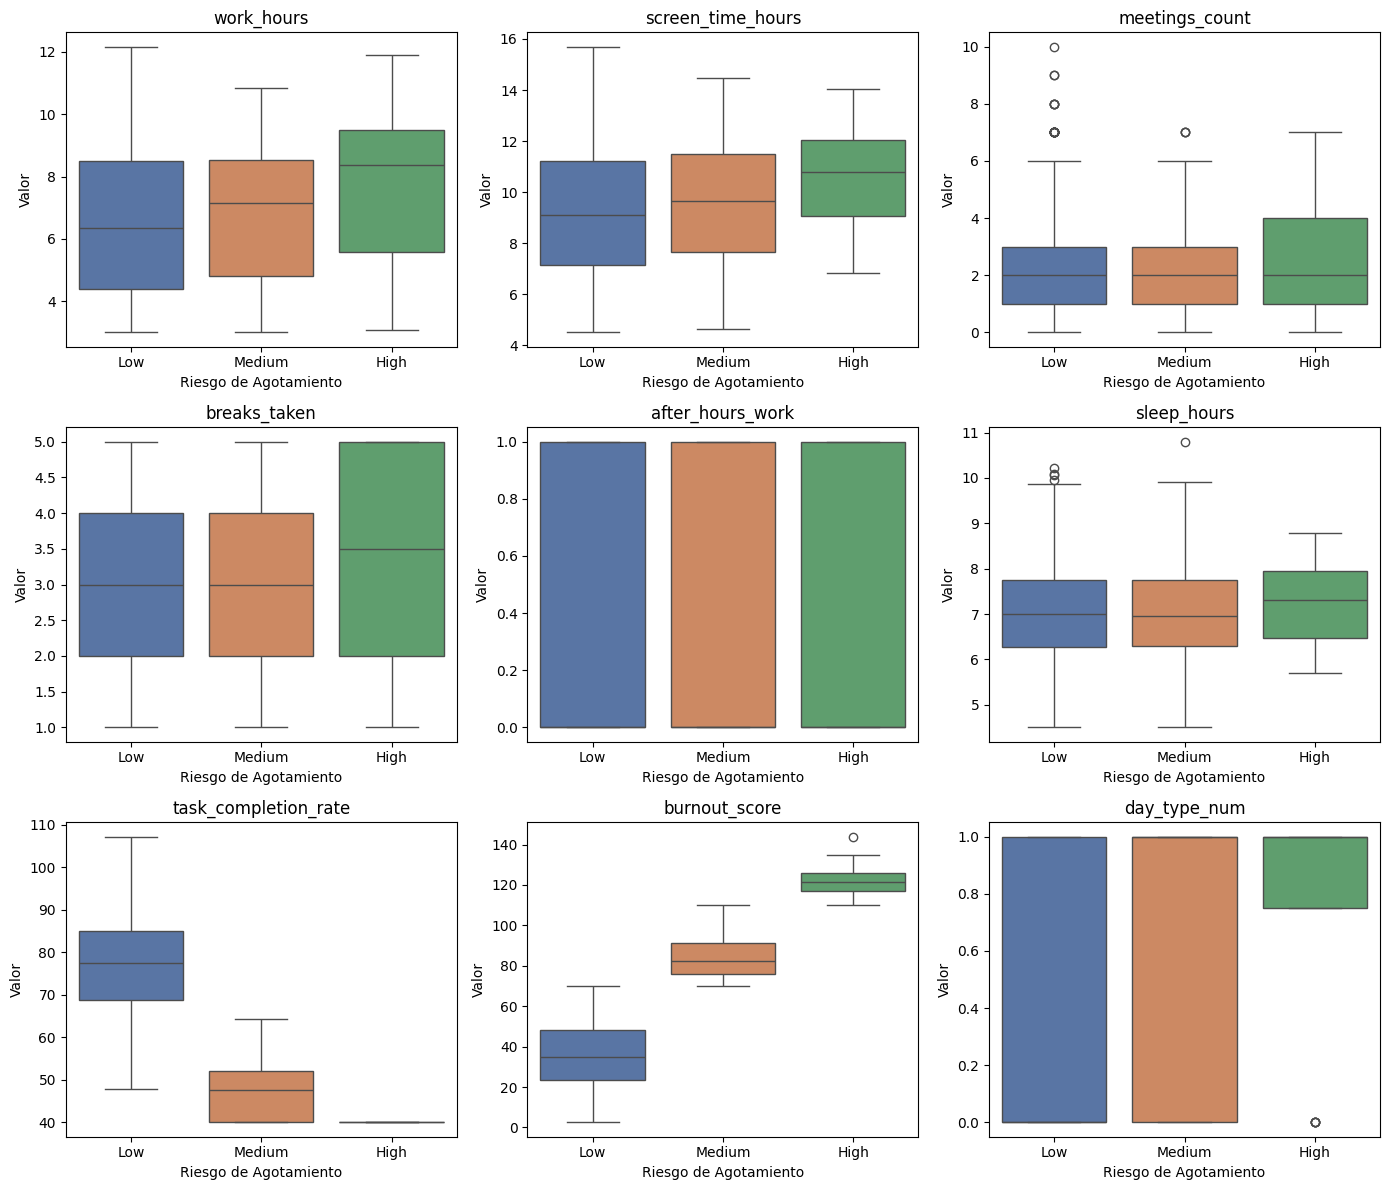

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(X_independientes.columns):
    sns.boxplot(data=datos, x="burnout_risk", y=col, ax=axes[i], order=["Low", "Medium", "High"], palette="deep")
    axes[i].set_title(col)
    axes[i].set_xlabel("Riesgo de Agotamiento")
    axes[i].set_ylabel("Valor")
for j in range(len(X_independientes.columns), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

Mostramos la matriz de correlación entre las variables independientes numéricas.

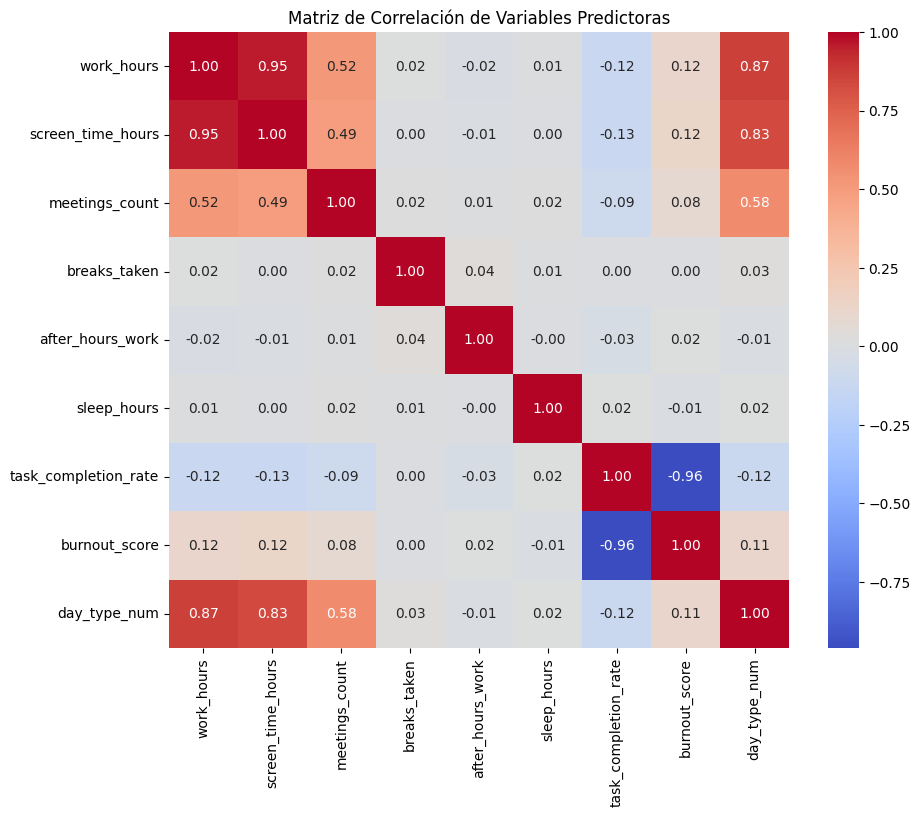

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_independientes.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Predictoras")
plt.show()

Representamos un gráfico de dispersión de dos de las variables predictoras más representativas (`burnout_score` y `sleep_hours`) coloreadas por la variable respuesta, siguiendo el estilo de visualización del scatterplot en los ejemplos de las clases.

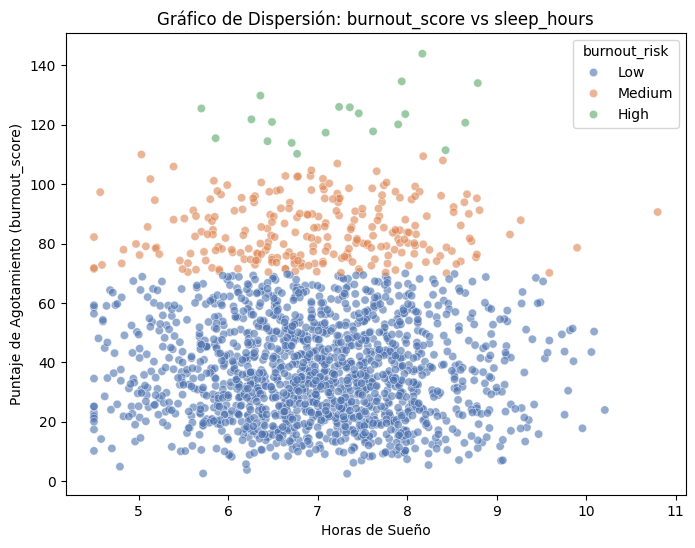

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=datos, x="sleep_hours", y="burnout_score", hue="burnout_risk", alpha=0.6, hue_order=["Low", "Medium", "High"], palette="deep")
plt.title("Gráfico de Dispersión: burnout_score vs sleep_hours")
plt.xlabel("Horas de Sueño")
plt.ylabel("Puntaje de Agotamiento (burnout_score)")
plt.show()

### b) División del conjunto de datos
Dividimos el conjunto de datos en un 80% para entrenamiento y un 20% para validación, fijando la semilla aleatoria `random_state` con el carnet de estudiante `20231085`.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_independientes, y_dependiente, test_size=0.20, random_state=20231085)
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de validación:", X_test.shape)

Tamaño del conjunto de entrenamiento: (1440, 9)
Tamaño del conjunto de validación: (360, 9)


### c) Modelo KNN con dos variables predictoras
Para este modelo se utilizarán las variables predictoras `burnout_score` y `sleep_hours` debido a su correlación teórica directa con el riesgo de agotamiento laboral. 
Estandarizamos las variables utilizando `StandardScaler` sobre el conjunto total y luego aplicamos la partición, emulando la metodología empleada en las clases de KNN.

In [18]:
X2_indep = X_independientes[["burnout_score", "sleep_hours"]]

# Estandarizar las variables independientes
scaler2 = StandardScaler()
scaler2.fit(X2_indep)
X2_est = scaler2.transform(X2_indep)

# Partición de datos
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_est, y_dependiente, test_size=0.20, random_state=20231085)

Utilizamos validación cruzada con 10 pliegues (cv=10) para encontrar el valor de $k$ que maximiza el accuracy score.

In [19]:
k_range = range(1, 100)
k_scores2 = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X2_train, y2_train, cv=10, scoring="accuracy")
    k_scores2.append(scores.mean())

Graficamos el accuracy promedio de validación cruzada para cada valor de $k$.

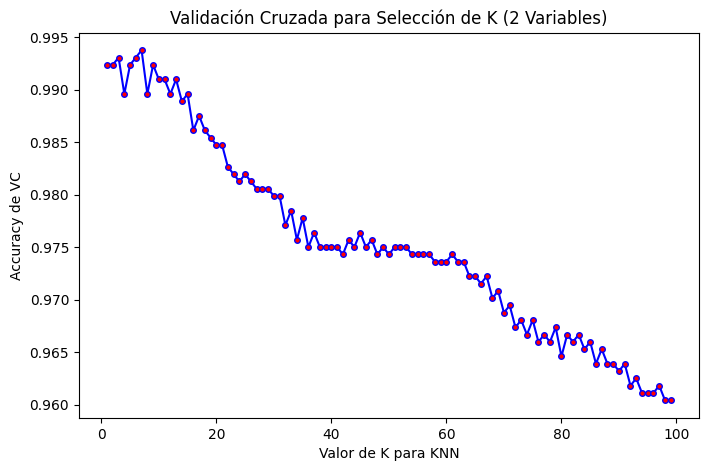

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, k_scores2, color="blue", linestyle="-", marker="o", markerfacecolor="red", markersize=4)
plt.xlabel("Valor de K para KNN")
plt.ylabel("Accuracy de VC")
plt.title("Validación Cruzada para Selección de K (2 Variables)")
plt.show()

In [21]:
mejor_k2 = np.argmax(k_scores2) + 1
print("El valor de K que maximiza la accuracy es", mejor_k2)

El valor de K que maximiza la accuracy es 7


Entrenamos el modelo KNN final utilizando las dos variables predictoras y el valor óptimo de $k$ encontrado.

In [22]:
model_KNN_2v = KNeighborsClassifier(n_neighbors=mejor_k2)
model_KNN_2v.fit(X2_train, y2_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(7)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Evaluamos el rendimiento del modelo en el conjunto de prueba para obtener el accuracy score, la matriz de confusión y las métricas de precisión, recall y F1. Como se trata de una clasificación multiclase, se aplica la opción `average="macro"

In [24]:
y_pred_knn2 = model_KNN_2v.predict(X2_test)
accuracy_knn2 = accuracy_score(y2_test, y_pred_knn2)
print("El accuracy score que se tiene es %s" %accuracy_knn2)

El accuracy score que se tiene es 0.9888888888888889


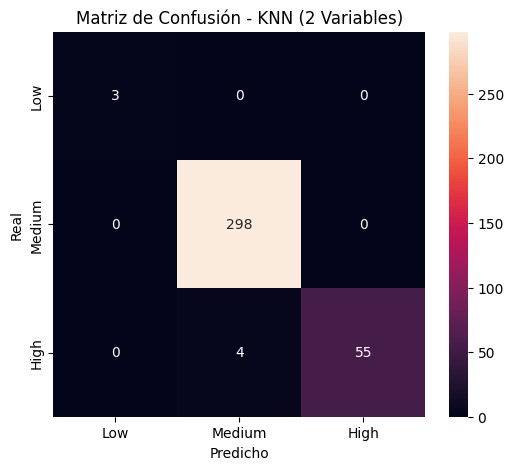

In [25]:
# Obtener la matriz de confusión
cm_knn2 = confusion_matrix(y2_test, y_pred_knn2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn2, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - KNN (2 Variables)")
plt.show()

In [26]:
# Obtener la precisión, recall y f1
precision_knn2 = precision_score(y2_test, y_pred_knn2, average="macro")
recall_knn2 = recall_score(y2_test, y_pred_knn2, average="macro")
f1_knn2 = f1_score(y2_test, y_pred_knn2, average="macro")

metricas_knn2 = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_knn2, recall_knn2, f1_knn2]})
metricas_knn2

,Métricas,Valores
0,Precisión,0.995585
1,Recall,0.977401
2,F1,0.986082


### d) Modelo KNN con todas las variables predictoras
Estandarizamos el conjunto de datos completo (todas las variables predictoras) y dividimos los datos en entrenamiento y validación de la misma forma.

In [27]:
# Estandarizar todas las variables
scaler_all = StandardScaler()
scaler_all.fit(X_independientes)
X_all_est = scaler_all.transform(X_independientes)

# Partición de datos
X_train_est, X_test_est, y_train_est, y_test_est = train_test_split(X_all_est, y_dependiente, test_size=0.20, random_state=20231085)

Buscamos el valor de $k$ óptimo empleando validación cruzada con 10 pliegues.

In [28]:
k_scores_all = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_est, y_train_est, cv=10, scoring="accuracy")
    k_scores_all.append(scores.mean())

Graficamos el accuracy promedio de validación cruzada para cada valor de $k$ con todas las variables predictoras.

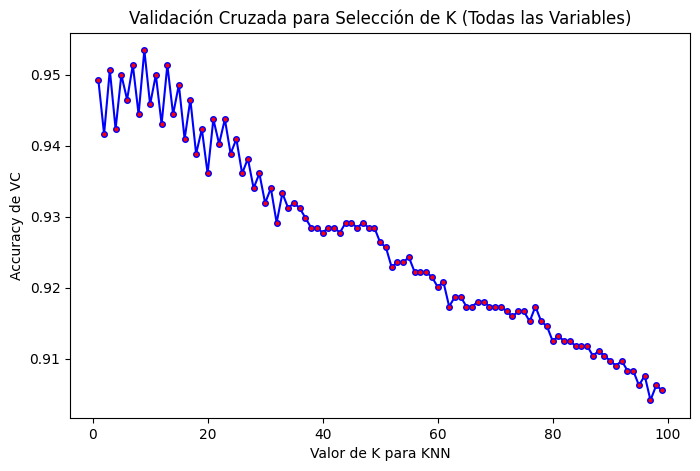

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, k_scores_all, color="blue", linestyle="-", marker="o", markerfacecolor="red", markersize=4)
plt.xlabel("Valor de K para KNN")
plt.ylabel("Accuracy de VC")
plt.title("Validación Cruzada para Selección de K (Todas las Variables)")
plt.show()

In [30]:
mejor_k_all = np.argmax(k_scores_all) + 1
print("El valor de K que maximiza la accuracy es", mejor_k_all)

El valor de K que maximiza la accuracy es 9


Entrenamos el modelo KNN final utilizando todas las variables predictoras estandarizadas y el valor de $k$ óptimo.

In [31]:
model_KNN_all = KNeighborsClassifier(n_neighbors=mejor_k_all)
model_KNN_all.fit(X_train_est, y_train_est)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(9)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [32]:
y_pred_knn_all = model_KNN_all.predict(X_test_est)
accuracy_knn_all = accuracy_score(y_test_est, y_pred_knn_all)
print("El accuracy score que se tiene es %s" %accuracy_knn_all)

El accuracy score que se tiene es 0.9583333333333334


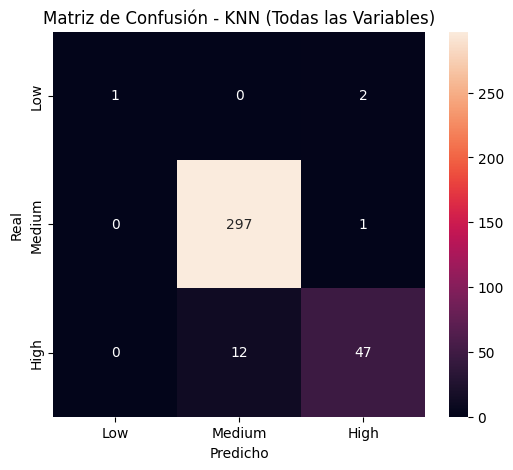

In [33]:
# Obtener la matriz de confusión
cm_knn_all = confusion_matrix(y_test_est, y_pred_knn_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn_all, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - KNN (Todas las Variables)")
plt.show()

In [34]:
# Obtener la precisión, recall y f1
precision_knn_all = precision_score(y_test_est, y_pred_knn_all, average="macro")
recall_knn_all = recall_score(y_test_est, y_pred_knn_all, average="macro")
f1_knn_all = f1_score(y_test_est, y_pred_knn_all, average="macro")

metricas_knn_all = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_knn_all, recall_knn_all, f1_knn_all]})
metricas_knn_all

,Métricas,Valores
0,Precisión,0.967055
1,Recall,0.708863
2,F1,0.780323


### e) Árbol de Decisión
Entrenamos un modelo de árbol de decisión sobre los datos no estandarizados (ya que los árboles no requieren escala), indicando que el número mínimo de observaciones en cada nodo hoja es de 100 (`min_samples_leaf=100`) y fijando la semilla en `random_state=20231085`.

In [35]:
tree_clf = DecisionTreeClassifier(min_samples_leaf=100, random_state=20231085)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",100
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20231085
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the

Representamos visualmente la estructura del árbol de decisión

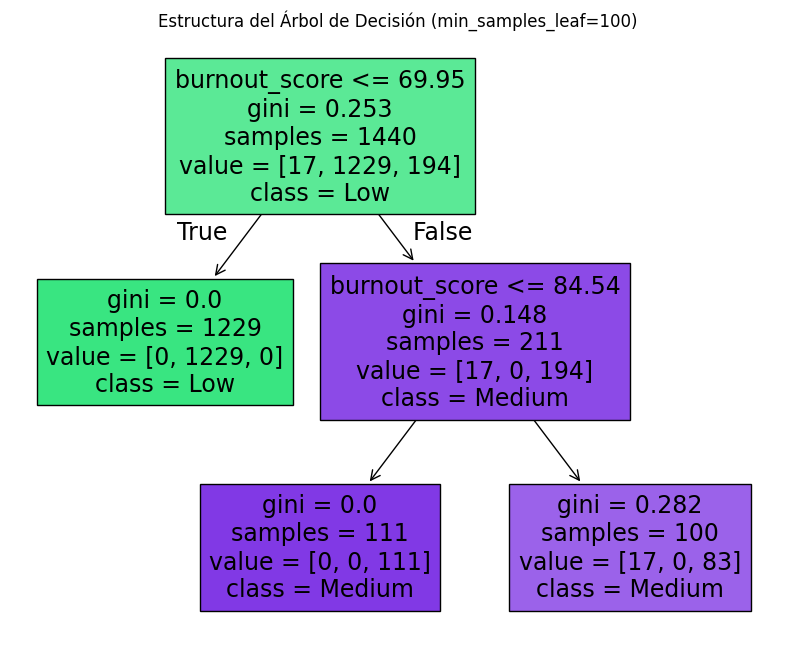

In [71]:
plt.figure(figsize=(10, 8))
tree.plot_tree(tree_clf, filled=True, feature_names=list(X_train.columns), class_names=list(tree_clf.classes_))
plt.title("Estructura del Árbol de Decisión (min_samples_leaf=100)")
plt.show()

Evaluamos el modelo de árbol de decisión en el conjunto de validación.

In [37]:
y_pred_tree = tree_clf.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("El accuracy score que se tiene es %s" %accuracy_tree)

El accuracy score que se tiene es 0.9916666666666667


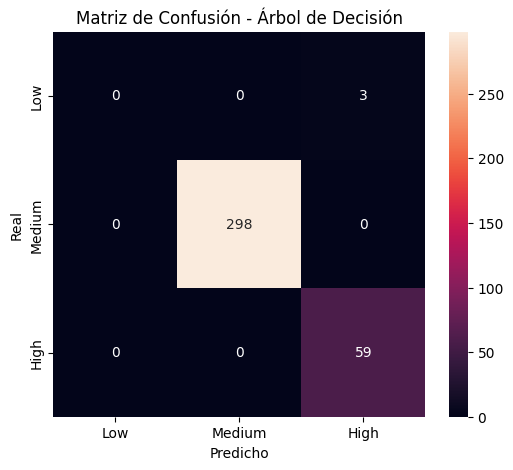

In [38]:
# Obtener la matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

In [39]:
# Obtener la precisión, recall y f1
precision_tree = precision_score(y_test, y_pred_tree, average="macro")
recall_tree = recall_score(y_test, y_pred_tree, average="macro")
f1_tree = f1_score(y_test, y_pred_tree, average="macro")

metricas_tree = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_tree, recall_tree, f1_tree]})
metricas_tree

,Métricas,Valores
0,Precisión,0.650538
1,Recall,0.666667
2,F1,0.658402


### f) Modelos de Ensamble

#### 1. Ensamble con reemplazamiento (Bagging)
Entrenamos un modelo de Bagging con 200 estimadores de árboles de decisión, bootstrap=True (con reemplazo) y max_samples=75, emulando los parámetros vistos en la Clase 19.

In [40]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, max_samples=75, bootstrap=True, random_state=20231085)
bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",200
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",75
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",20231085
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [41]:
y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print("El accuracy score que se tiene es %s" %accuracy_bag)

El accuracy score que se tiene es 0.9944444444444445


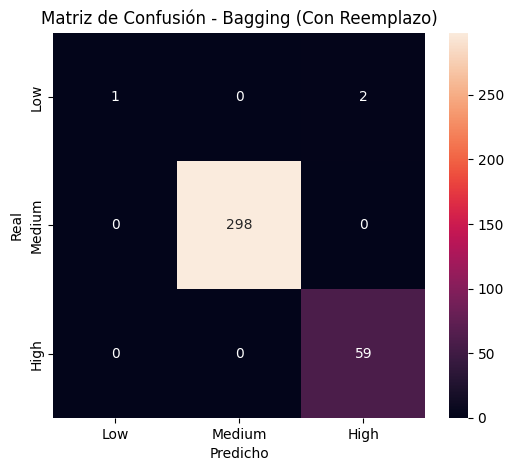

In [42]:
# Obtener la matriz de confusión
cm_bag = confusion_matrix(y_test, y_pred_bag)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bag, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Bagging (Con Reemplazo)")
plt.show()

In [43]:
# Obtener la precisión, recall y f1
precision_bag = precision_score(y_test, y_pred_bag, average="macro")
recall_bag = recall_score(y_test, y_pred_bag, average="macro")
f1_bag = f1_score(y_test, y_pred_bag, average="macro")

metricas_bag = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_bag, recall_bag, f1_bag]})
metricas_bag

,Métricas,Valores
0,Precisión,0.989071
1,Recall,0.777778
2,F1,0.827778


#### 2. Ensamble sin reemplazamiento (Pasting)
Entrenamos un modelo de Pasting con 200 estimadores de árboles de decisión, bootstrap=False (sin reemplazo) y max_samples=75

In [44]:
pas_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, max_samples=75, bootstrap=False, random_state=20231085)
pas_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",200
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",75
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",20231085
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [49]:
y_pred_pas = pas_clf.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)

El accuracy score que se tiene es 0.9944444444444445


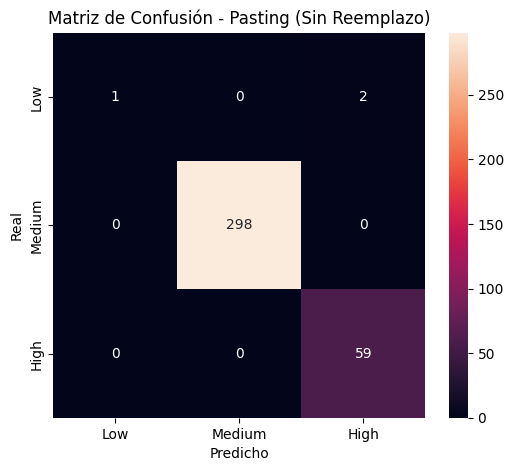

In [50]:
# Obtener la matriz de confusión
cm_pas = confusion_matrix(y_test, y_pred_pas)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pas, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Pasting (Sin Reemplazo)")
plt.show()

In [51]:
# Obtener la precisión, recall y f1
precision_pas = precision_score(y_test, y_pred_pas, average="macro")
recall_pas = recall_score(y_test, y_pred_pas, average="macro")
f1_pas = f1_score(y_test, y_pred_pas, average="macro")

metricas_pas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_pas, recall_pas, f1_pas]})
metricas_pas

,Métricas,Valores
0,Precisión,0.989071
1,Recall,0.777778
2,F1,0.827778


#### 3. Random Forest (Fijando el número de nodos hoja máximo a 8)
Ajustamos un modelo de Random Forest con 200 árboles de decisión, restringiendo el máximo de nodos hoja por árbol a 8 y fijando la semilla en `20231085`.

In [52]:
rnd_clf = RandomForestClassifier(n_estimators=200, max_leaf_nodes=8, random_state=20231085)
rnd_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",8
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [53]:
y_pred_rf = rnd_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("El accuracy score que se tiene es %s" %accuracy_rf)

El accuracy score que se tiene es 1.0


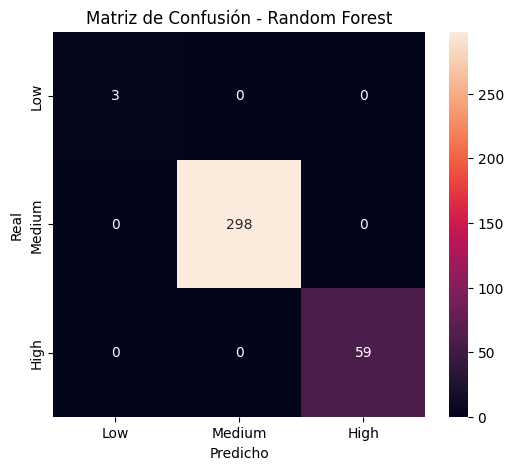

In [54]:
# Obtener la matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [55]:
# Obtener la precisión, recall y f1
precision_rf = precision_score(y_test, y_pred_rf, average="macro")
recall_rf = recall_score(y_test, y_pred_rf, average="macro")
f1_rf = f1_score(y_test, y_pred_rf, average="macro")

metricas_rf = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_rf, recall_rf, f1_rf]})
metricas_rf

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


Mostramos las importancias de las variables independientes calculadas por el modelo Random Forest.

In [56]:
importancias = pd.DataFrame({"Variable": X_train.columns, "Importancia": rnd_clf.feature_importances_})
importancias = importancias.sort_values(by="Importancia", ascending=False)
importancias

,Variable,Importancia
7,burnout_score,0.611905
6,task_completion_rate,0.361028
0,work_hours,0.008185
1,screen_time_hours,0.007819
5,sleep_hours,0.005847
3,breaks_taken,0.002201
2,meetings_count,0.001973
8,day_type_num,0.000619
4,after_hours_work,0.000424


#### 4. Gradient Boosting
Entrenamos primero un modelo de Gradient Boosting básico (con los parámetros por defecto del algoritmo y 200 estimadores) para tener un punto de partida.

In [57]:
gb_clf = GradientBoostingClassifier(n_estimators=200, random_state=20231085)
gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [58]:
y_pred_gb = gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("El accuracy score que se tiene es %s" %accuracy_gb)

El accuracy score que se tiene es 1.0


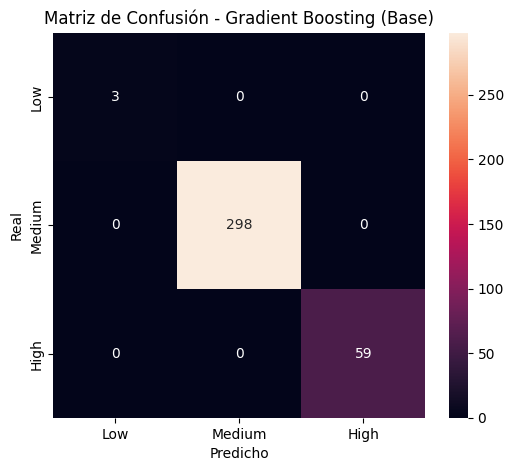

In [59]:
# Obtener la matriz de confusión
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Gradient Boosting (Base)")
plt.show()

In [60]:
# Obtener la precisión, recall y f1
precision_gb = precision_score(y_test, y_pred_gb, average="macro")
recall_gb = recall_score(y_test, y_pred_gb, average="macro")
f1_gb = f1_score(y_test, y_pred_gb, average="macro")

metricas_gb = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb, recall_gb, f1_gb]})
metricas_gb

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


#### 5. Gradient Boosting Ajustado
Para el ajuste fino del modelo de Gradient Boosting, creamos un bucle manual para probar diferentes valores de tasa de aprendizaje (`learning_rate`) y profundidad máxima (`max_depth`)

In [61]:
# Crear un conjunto de posibles valores
learning_rates = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
max_depths = [2, 3, 4, 5]

# Inicializamos los vectores de resultados
resultados_test = list()

# Bucle para extraer resultados
for d in max_depths:
    for eta in learning_rates:
        gb_clf_i = GradientBoostingClassifier(learning_rate=eta, n_estimators=200, random_state=20231085, max_depth=d)
        # Entrenamos al modelo
        gb_clf_i.fit(X_train, y_train)
        # Predicción sobre la muestra de validación
        y_pred_test = gb_clf_i.predict(X_test)
        # Accuracy de entrenamiento/prueba
        acc_test = accuracy_score(y_test, y_pred_test)
        # Guardar resultados en el vector
        resultados_test.append(acc_test)

Graficamos los resultados obtenidos en el ajuste de hiperparámetros de Gradient Boosting.

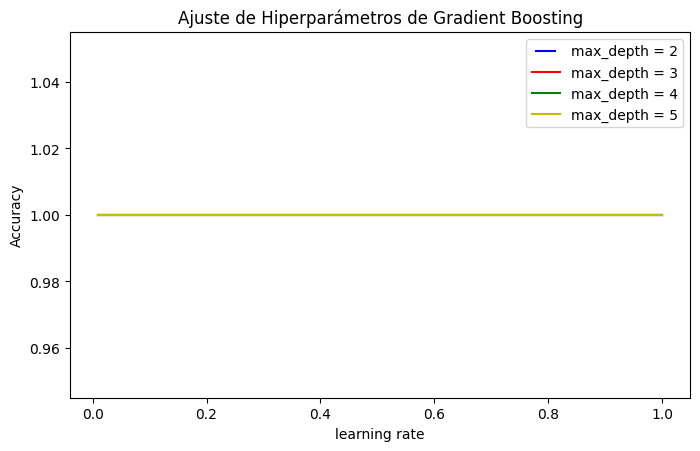

In [62]:
from matplotlib.legend_handler import HandlerLine2D

plt.figure(figsize=(8, 4.75))
line1, = plt.plot(learning_rates, resultados_test[0:6], "b", label="max_depth = 2")
line2, = plt.plot(learning_rates, resultados_test[6:12], "r", label="max_depth = 3")
line3, = plt.plot(learning_rates, resultados_test[12:18], "g", label="max_depth = 4")
line4, = plt.plot(learning_rates, resultados_test[18:24], "y", label="max_depth = 5")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=4)})
plt.ylabel("Accuracy")
plt.xlabel("learning rate")
plt.title("Ajuste de Hiperparámetros de Gradient Boosting")
plt.show()

A partir del análisis gráfico, todas las combinaciones proporcionan un accuracy de 1.0 (debido a la perfecta delimitación lineal que aporta la variable `burnout_score`). Procedemos a instanciar el modelo con parámetros balanceados: `max_depth=2` y `learning_rate=0.1`.

In [63]:
gb_clf_b = GradientBoostingClassifier(max_depth=2, learning_rate=0.1, n_estimators=200, random_state=20231085)
gb_clf_b.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [64]:
y_pred_gb_b = gb_clf_b.predict(X_test)
accuracy_gb_b = accuracy_score(y_test, y_pred_gb_b)
print("El accuracy score que se tiene es %s" %accuracy_gb_b)

El accuracy score que se tiene es 1.0


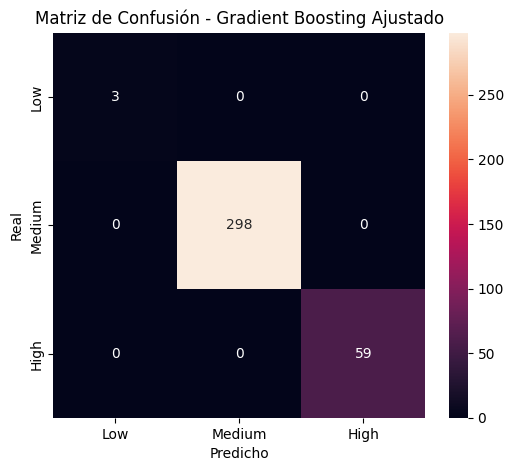

In [65]:
# Obtener la matriz de confusión
cm_gb_b = confusion_matrix(y_test, y_pred_gb_b)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb_b, annot=True, fmt="d", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Gradient Boosting Ajustado")
plt.show()

In [66]:
# Obtener la precisión, recall y f1
precision_gb_b = precision_score(y_test, y_pred_gb_b, average="macro")
recall_gb_b = recall_score(y_test, y_pred_gb_b, average="macro")
f1_gb_b = f1_score(y_test, y_pred_gb_b, average="macro")

metricas_gb_b = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb_b, recall_gb_b, f1_gb_b]})
metricas_gb_b

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


#### 6. Comparativa General de los Modelos Ajustados
Creamos un DataFrame comparativo con los accuracies, precisiones, recalls y F1 scores de todos los modelos implementados en el parcial, agregando una columna con el valor promedio de dichas métricas.

In [67]:
modelos = [
    "KNN (2 Variables)",
    "KNN (Todas las Variables)",
    "Árbol de Decisión",
    "Bagging",
    "Pasting",
    "Random Forest",
    "Gradient Boosting Base",
    "Gradient Boosting Ajustado"
]

accuracy_scores = [accuracy_knn2, accuracy_knn_all, accuracy_tree, accuracy_bag, accuracy_pas, accuracy_rf, accuracy_gb, accuracy_gb_b]
precision_scores = [precision_knn2, precision_knn_all, precision_tree, precision_bag, precision_pas, precision_rf, precision_gb, precision_gb_b]
recall_scores = [recall_knn2, recall_knn_all, recall_tree, recall_bag, recall_pas, recall_rf, recall_gb, recall_gb_b]
f1_scores = [f1_knn2, f1_knn_all, f1_tree, f1_bag, f1_pas, f1_rf, f1_gb, f1_gb_b]

resultados = pd.DataFrame({
    "Modelos": modelos,
    "Accuracy": accuracy_scores,
    "Precisión": precision_scores,
    "Recall": recall_scores,
    "F1 Score": f1_scores
})

resultados["Media"] = np.mean(resultados.drop("Modelos", axis=1), axis=1)
resultados = resultados.sort_values(by="Media", ascending=False).reset_index(drop=True)
resultados

,Modelos,Accuracy,Precisión,Recall,F1 Score,Media
0,Gradient Boosting Base,1.000000,1.000000,1.000000,1.000000,1.000000
1,Gradient Boosting Ajustado,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,KNN (2 Variables),0.988889,0.995585,0.977401,0.986082,0.986989
4,Bagging,0.994444,0.989071,0.777778,0.827778,0.897268
5,Pasting,0.994444,0.989071,0.777778,0.827778,0.897268
6,KNN (Todas las Variables),0.958333,0.967055,0.708863,0.780323,0.853643
7,Árbol de Decisión,0.991667,0.650538,0.666667,0.658402,0.741818


### g) Clasificación para la moda de las variables predictoras
Obtenemos la moda de las variables predictoras del conjunto de datos completo y realizamos la clasificación empleando el modelo con mejor rendimiento de la tabla comparativa (el cual puede ser Random Forest o Gradient Boosting).

In [68]:
# Seleccionamos el mejor modelo según el ranking
mejor_modelo_nombre = resultados.loc[0, "Modelos"]
print("El modelo seleccionado con mejor rendimiento es:", mejor_modelo_nombre)

# En base al nombre del modelo, asignamos el objeto clf correspondiente
if mejor_modelo_nombre == "Random Forest":
    mejor_modelo = rnd_clf
elif mejor_modelo_nombre == "Gradient Boosting Ajustado":
    mejor_modelo = gb_clf_b
elif mejor_modelo_nombre == "Gradient Boosting Base":
    mejor_modelo = gb_clf
elif mejor_modelo_nombre == "Bagging":
    mejor_modelo = bag_clf
elif mejor_modelo_nombre == "Pasting":
    mejor_modelo = pas_clf
elif mejor_modelo_nombre == "Árbol de Decisión":
    mejor_modelo = tree_clf
elif mejor_modelo_nombre == "KNN (Todas las Variables)":
    mejor_modelo = model_KNN_all
elif mejor_modelo_nombre == "KNN (2 Variables)":
    mejor_modelo = model_KNN_2v

El modelo seleccionado con mejor rendimiento es: Gradient Boosting Base


In [69]:
# Cálculo de la moda
x_moda = X_independientes.mode().iloc[[0]]
x_moda

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,day_type_num
0,3.0,11.93,1.0,4.0,0.0,4.5,40.0,22.36,0.0


In [70]:
# Realizar la predicción final
if mejor_modelo_nombre == "KNN (Todas las Variables)":
    x_moda_est = scaler_all.transform(x_moda)
    prediccion_moda = mejor_modelo.predict(x_moda_est)
elif mejor_modelo_nombre == "KNN (2 Variables)":
    x_moda_2 = x_moda[["burnout_score", "sleep_hours"]]
    x_moda_est2 = scaler2.transform(x_moda_2)
    prediccion_moda = mejor_modelo.predict(x_moda_est2)
else:
    prediccion_moda = mejor_modelo.predict(x_moda)

print("La clase de riesgo de agotamiento (burnout_risk) predicha para la persona con la moda de las variables predictoras es: %s" %prediccion_moda[0])

La clase de riesgo de agotamiento (burnout_risk) predicha para la persona con la moda de las variables predictoras es: Low
